In [1]:
!pip install numpy
!pip install matplotlib
!pip install tqdm

In [2]:
!pip install kaggle-environments

In [3]:
!pip install torch --index-url https://download.pytorch.org/whl/cu130

Looking in indexes: https://download.pytorch.org/whl/cu130
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/2.0 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 GB 13.7 MB/s eta 0:02:25
   ---------------------------------------- 0.0/2.0 GB 14.6 MB/s eta 0:02:16
   ---------------------------------------- 0.0/2.0 GB 13.7 MB/s eta 0:02:25
   ---------------------------------------- 0.0/2.0 GB 14.1 MB/s eta 0:02:20
   ---------------------------------------- 0.0/2.0 GB 14.9 MB/s eta 0:02:13
   ---------------------------------------- 0.0/2.0 GB 15.7 MB/s eta 0:02:06
   ---------------------------------------- 0.0/2.0 GB 15.6 MB/s eta 0:02:06
    --------------------------------------- 0.0/2.0 GB 16.1 MB/s eta 0:02:02
    --------------------------------------- 0.0/2.0 GB 15.6 MB/s e

In [4]:
import numpy as np
print(np.__version__)
import math

import torch
print(torch.__version__)
import torch._utils

import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)

from tqdm.notebook import trange

import random

import matplotlib.pyplot as plt

import time

2.4.6
2.14.0+cu130


In [5]:
import torch
import torch._utils

print(torch.__version__)
print(torch._utils)
print(hasattr(torch, "_utils"))
print(torch.__file__)
print(torch.optim.__file__)

2.14.0+cu130
<module 'torch._utils' from 'C:\\Users\\csong\\Desktop\\python_project\\AlphaZero\\.venv\\Lib\\site-packages\\torch\\_utils.py'>
True
C:\Users\csong\Desktop\python_project\AlphaZero\.venv\Lib\site-packages\torch\__init__.py
C:\Users\csong\Desktop\python_project\AlphaZero\.venv\Lib\site-packages\torch\optim\__init__.py


In [6]:
class TicTacToe:
    def __init__(self):
        self.column_count = 3
        self.row_count = 3
        self.action_size = 9

    def __repr__(self):
        return "TicTacToe"
        
    def get_initial_state(self):
        return np.zeros((self.row_count, self.column_count))

    def get_next_state(self, state, action, player):
        row = action // self.row_count 
        column = action % self.column_count
        state[row, column] = player
        return state

    def get_valid_moves(self, state): #returns a flat 1d array with 0's and 1's; 0's represent not valid move, 1's represent valid
        return (state.reshape(-1)==0).astype(np.uint8)

    def check_win(self, state, action): #checks if a certain action wins the game
        if action == None:
            return False
        row = action // self.row_count
        column = action % self.column_count
        player = state[row, column]
        return(
            np.sum(state[row, :]) == player * self.column_count #note: opponent is the negative value of the player
            or np.sum(state[:, column]) == player * self.row_count
            or np.sum(np.diag(state)) == player * self.row_count
            or np.sum(np.diag(np.flip(state, axis = 1))) == player * self.row_count
        )
        
    def get_value_and_terminated (self, state, action):
        if self.check_win(state, action):
            return 1, True
        if np.sum(self.get_valid_moves(state)) == 0:
            return 0, True
        return 0, False

    def get_opponent(self, player):
        return -player

    def get_opponent_value(self, value):
        return -value

    def change_perspective(self, state, player):
        return state*player

    def get_encoded_state(self, state):
        encoded_state = np.stack(
            (state == -1, state == 0, state ==1)
        ).astype(np.float32)
        
        if len(state.shape)==3:
            encoded_state = np.swapaxes(encoded_state, 0, 1)
            
        return encoded_state

In [7]:
class ConnectFour:
    def __init__(self):
        self.column_count = 7
        self.row_count = 6
        self.action_size = self.column_count
        self.in_a_row = 4

    def __repr__(self):
        return "ConnectFour"
        
    def get_initial_state(self):
        return np.zeros((self.row_count, self.column_count))

    def get_next_state(self, state, action, player):
        row = np.max(np.where(state[:, action]==0))
        state[row, action] = player
        return state

    def get_valid_moves(self, state): #returns a flat 1d array with 0's and 1's; 0's represent not valid move, 1's represent valid
        return (state[0]==0).astype(np.uint8)

    def check_win(self, state, action): #checks if a certain action wins the game
        if action == None:
            return False
        row = np.min(np.where(state[:, action] != 0))
        column = action
        player = state[row][column]

        def count(offset_row, offset_column):
            for i in range(1, self.in_a_row):
                r = row + offset_row * i
                c = action + offset_column * i
                if (
                    r < 0 
                    or r >= self.row_count
                    or c < 0 
                    or c >= self.column_count
                    or state[r][c] != player
                ):
                    return i - 1
            return self.in_a_row - 1

        return (
            count(1, 0) >= self.in_a_row - 1 # vertical
            or (count(0, 1) + count(0, -1)) >= self.in_a_row - 1 # horizontal
            or (count(1, 1) + count(-1, -1)) >= self.in_a_row - 1 # top left diagonal
            or (count(1, -1) + count(-1, 1)) >= self.in_a_row - 1 # top right diagonal
        )
        
    def get_value_and_terminated (self, state, action):
        if self.check_win(state, action):
            return 1, True
        if np.sum(self.get_valid_moves(state)) == 0:
            return 0, True
        return 0, False

    def get_opponent(self, player):
        return -player

    def get_opponent_value(self, value):
        return -value

    def change_perspective(self, state, player):
        return state*player

    def get_encoded_state(self, state):
        encoded_state = np.stack(
            (state == -1, state == 0, state ==1)
        ).astype(np.float32)

        if len(state.shape)==3:
            encoded_state = np.swapaxes(encoded_state, 0, 1)
        
        return encoded_state

In [55]:
class Node_Non_alpha: #the node for a non-alphaMCTS tree; this breaks because it calls itself. ignore for now
    def __init__(self, game, args, state, parent = None, action_taken = None):
        self.game = game
        self.args = args
        self.state = state
        self.parent = parent
        self.action_taken = action_taken

        self.children = []
        self.expandable_moves = game.get_valid_moves(state)

        self.visit_count = 0
        self.value_sum = 0

    def is_fully_expanded(self):
        return np.sum(self.expandable_moves) == 0 and len(self.children)>0

    def select(self):
        #MCTS selection
        best_child = None
        best_ucb = -np.inf

        for child in self.children:
            ucb = self.get_ucb(child)
            if(ucb > best_ucb):
                best_child = child
                best_ucb = ucb
        return best_child

    def get_ucb(self, child): #pass in a child and it will return the ucb of that child
        q_value = 1 - ((child.value_sum / child.visit_count) + 1)/2 #value sum is between -1 and 1, +1 /2 makes it between 0 and 1 
        #1 - UCB because we switch players every time in tic tac toe so we select the worst for opponent (tree flips parity)
        return q_value + self.args['C'] * math.sqrt(math.log(self.visit_count)/child.visit_count)

    def expand(self):
        action = np.random.choice(np.where(self.expandable_moves == 1)[0])
        self.expandable_moves[action] = 0 

        child_state = self.state.copy()
        child_state = self.game.get_next_state(child_state, action, 1)
        child_state = self.game.change_perspective(child_state, player = -1) #multiplies everything by -1 to be shipped off to the child

        child = Node(self.game, self.args, child_state, self, action);
        self.children.append(child)
        return child

    def simulate(self):
        value, is_terminal = self.game.get_value_and_terminated(self.state, self.action_taken)
        value = self.game.get_opponent_value(value)

        if is_terminal:
            return value

        rollout_state = self.state.copy()
        rollout_player = 1

        while True:
            valid_moves = self.game.get_valid_moves(rollout_state)
            action = np.random.choice(np.where(valid_moves == 1)[0])
            rollout_state = self.game.get_next_state(rollout_state, action, rollout_player)
            value, is_terminal = self.game.get_value_and_terminated(rollout_state, action)

            if is_terminal:
                if rollout_player == -1:
                    value = self.game.get_opponent_value(value)
                return value

            rollout_player = self.game.get_opponent(rollout_player)

    def backpropogate(self, value):
        self.value_sum += value
        self.visit_count += 1

        value = self.game.get_opponent_value(value)

        if self.parent is not None:
            self.parent.backpropogate(value)

class MCTS:
    def __init__(self, game, args):
        self.game = game
        self.args = args

    def search(self, state):
        #define root
        root = Node(self.game, self.args, state)
        
        for search in range(self.args['num_searches']):
            node = root

            #selection
            while node.is_fully_expanded():
                node = node.select()

            value, is_terminal = self.game.get_value_and_terminated(node.state, node.action_taken) #action taken is the action of the parent (aka opponent)
            value = self.game.get_opponent_value(value)
            
            if not is_terminal:
                #expansion
                node = node.expand()

                #simulation
                value = node.simulate()
            
            #backpropogation
            node.backpropogate(value)
        
        #return visit count
        action_probs = np.zeros(self.game.action_size)
        for child in root.children:
            action_probs[child.action_taken] = child.visit_count
        action_probs /= np.sum(action_probs)
        return action_probs

In [8]:
class ResNet(nn.Module):
    def __init__(self, game, num_resBlocks, num_hidden, device):
        super().__init__()
        
        self.device = device
        self.startBlock = nn.Sequential(
            nn.Conv2d(3, num_hidden, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(num_hidden),
            nn.ReLU()
        )

        self.backBone = nn.ModuleList(
            [ResBlock(num_hidden) for i in range(num_resBlocks) ]
        )

        self.policyHead = nn.Sequential(
            nn.Conv2d(num_hidden, 32, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32*game.row_count * game.column_count, game.action_size) #fully connected layer maps all 32 diff filters of map
        )

        self.valueHead = nn.Sequential(
            nn.Conv2d(num_hidden, 3, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3*game.row_count * game.column_count, 1),
            nn.Tanh()
        )

        self.to(device)

    def forward(self, x):
        x = self.startBlock(x)
        for resBlock in self.backBone:
            x = resBlock(x)
        policy = self.policyHead(x)
        value = self.valueHead(x)
        return policy, value

class ResBlock(nn.Module):
    def __init__(self, num_hidden):
        super().__init__()
        self.conv1 = nn.Conv2d(num_hidden, num_hidden, kernel_size = 3, padding = 1)
        self.bn1 = nn.BatchNorm2d(num_hidden)
        self.conv2 = nn.Conv2d(num_hidden, num_hidden, kernel_size = 3, padding = 1)
        self.bn2 = nn.BatchNorm2d(num_hidden)

    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x += residual
        x = F.relu(x)
        return x
        

0.9891328811645508
[[ 0.  0. -1.]
 [ 0. -1.  0.]
 [ 1.  0.  1.]]
tensor([[[[0., 0., 1.],
          [0., 1., 0.],
          [0., 0., 0.]],

         [[1., 1., 0.],
          [1., 0., 1.],
          [0., 1., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [1., 0., 1.]]]], device='cuda:0')
[1.0000376e-02 2.0905025e-02 8.3597435e-04 8.9835431e-03 7.4172240e-05
 1.4015633e-02 7.5395065e-03 9.3758672e-01 5.8993657e-05]


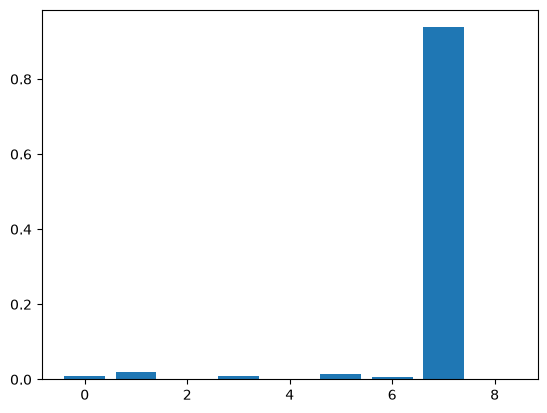

In [9]:
tictactoe = TicTacToe()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

state = tictactoe.get_initial_state()

state = tictactoe.get_next_state(state, 2, -1)
state = tictactoe.get_next_state(state, 6, 1)
state = tictactoe.get_next_state(state, 4, -1)
state = tictactoe.get_next_state(state, 8, 1)

encoded_state = tictactoe.get_encoded_state(state)

tensor_state = torch.tensor(encoded_state, device = device).unsqueeze(0)

model = ResNet(tictactoe, 4, 64, device = device) #resBlocks = 4, num hidden = 64
model.load_state_dict(torch.load('model_2.pt'))
model.eval()

policy, value = model(tensor_state)

value = value.item()
policy = torch.softmax(policy, axis = 1).squeeze(0).detach().cpu().numpy()

print(value)
print(state)
print(tensor_state)
print(policy)

plt.bar(range(tictactoe.action_size), policy)
plt.show()

In [8]:
valid_moves = tictactoe.get_valid_moves(state)
print(valid_moves)
policytest = policy * valid_moves
policytest/=sum(policytest)
print(policytest)

[1 1 0 1 0 1 0 1 0]


NameError: name 'policy' is not defined

In [10]:
class Node: #the node for a alpha MCTS
    def __init__(self, game, args, state, parent = None, action_taken = None, prior = 0, visit_count = 0):
        self.game = game
        self.args = args
        self.state = state
        self.parent = parent
        self.action_taken = action_taken
        self.prior = prior #prior is the policy from the parents perspective when we select this node
        
        self.children = []

        self.visit_count = visit_count
        self.value_sum = 0

    def is_fully_expanded(self):
        return len(self.children)>0

    def select(self):
        #MCTS selection
        best_child = None
        best_ucb = -np.inf

        for child in self.children:
            ucb = self.get_ucb(child)
            if(ucb > best_ucb):
                best_child = child
                best_ucb = ucb
        return best_child

    def get_ucb(self, child): #pass in a child and it will return the ucb of that child
        if(child.visit_count==0):
            q_value = 0
        else:
            q_value = 1 - ((child.value_sum / child.visit_count) + 1)/2 #value sum is between -1 and 1, +1 /2 makes it between 0 and 1 
            #1 - UCB because we switch players every time in tic tac toe so we select the worst for opponent (tree flips parity)
        
        
        return q_value + self.args['C']* (math.sqrt(self.visit_count) / (child.visit_count + 1)) * child.prior

    def expand(self, policy):
        for action, prob in enumerate(policy):
            if prob > 0:
                child_state = self.state.copy()
                child_state = self.game.get_next_state(child_state, action, 1)
                child_state = self.game.change_perspective(child_state, player = -1) #multiplies everything by -1 to be shipped off to the child
        
                child = Node(self.game, self.args, child_state, self, action, prob);
                self.children.append(child)
        return child

    def backpropogate(self, value):
        self.value_sum += value
        self.visit_count += 1

        value = self.game.get_opponent_value(value)

        if self.parent is not None:
            self.parent.backpropogate(value)
            
class AlphaMCTS:
    def __init__(self, game, args, model):
        self.game = game
        self.args = args
        self.model = model

    @torch.no_grad()
    def search(self, state):
        #define root
        root = Node(self.game, self.args, state, visit_count = 1)

        policy, _= self.model(
            torch.tensor(self.game.get_encoded_state(state), device = self.model.device).unsqueeze(0) 
        )
        policy = torch.softmax(policy, axis = 1).squeeze(0).cpu().numpy()
        policy = (1- self.args['dirichlet_epsilon'])*policy + self.args['dirichlet_epsilon'] \
            * np.random.dirichlet([self.args['dirichlet_alpha']]*self.game.action_size)

        valid_moves = self.game.get_valid_moves(state)
        policy *= valid_moves
        
        policy /= np.sum(policy)

        root.expand(policy)
        
        for search in range(self.args['num_searches']):
            node = root

            #selection
            while node.is_fully_expanded():
                node = node.select()

            value, is_terminal = self.game.get_value_and_terminated(node.state, node.action_taken) #action taken is the action of the parent (aka opponent)
            value = self.game.get_opponent_value(value)
            
            if not is_terminal: # use policy and value instead
                policy, value = self.model(
                    torch.tensor(self.game.get_encoded_state(node.state), device = self.model.device).unsqueeze(0)
                )
                policy = torch.softmax(policy, axis = 1).squeeze(0).cpu().numpy()
                valid_moves = self.game.get_valid_moves(node.state)
                policy *= valid_moves
                policy /= np.sum(policy)

                value = value.item()

                node.expand(policy)
            
            #backpropogation
            node.backpropogate(value)
        
        #return visit count
        action_probs = np.zeros(self.game.action_size)
        for child in root.children:
            action_probs[child.action_taken] = child.visit_count
        action_probs /= np.sum(action_probs)
        return action_probs

In [147]:
tictactoe = TicTacToe()
player = 1

args = {
    'C': 2,
    'num_searches': 1000
}

model = ResNet(tictactoe, 4, 64)
model.eval()

mcts = AlphaMCTS(tictactoe, args, model)

state = tictactoe.get_initial_state()

while True:
    print(state)
    if player == 1:
        valid_moves = tictactoe.get_valid_moves(state)
        print("Valid Moves: ", [i for i in range(tictactoe.action_size) if valid_moves[i] == 1])
        action = int(input(f"{player}:"))
        
        if(valid_moves[action] == 0):
            print("action not valid")
            continue

    else:
        neutral_state = tictactoe.change_perspective(state, player) #player always = -1
        mcts_probs = mcts.search(neutral_state)
        action = np.argmax(mcts_probs)

    state = tictactoe.get_next_state(state, action, player)
    value, is_terminal = tictactoe.get_value_and_terminated(state, action)

    if is_terminal:
        print(state)
        if value == 1:
            print("player", player, "won")
        if value == 0:
            print("draw")
        break

    player = tictactoe.get_opponent(player)


[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
Valid Moves:  [0, 1, 2, 3, 4, 5, 6, 7, 8]


1: 0


[[1. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
[[ 1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0.  0.]]
Valid Moves:  [1, 2, 3, 5, 6, 7, 8]


1: 2


[[ 1.  0.  1.]
 [ 0. -1.  0.]
 [ 0.  0.  0.]]
[[ 1.  0.  1.]
 [ 0. -1.  0.]
 [ 0. -1.  0.]]
Valid Moves:  [1, 3, 5, 6, 8]


1: 1


[[ 1.  1.  1.]
 [ 0. -1.  0.]
 [ 0. -1.  0.]]
player 1 won


In [43]:
class AlphaZero:
    def __init__(self, model, optimizer, game, args):
        self.model = model
        self.optimizer = optimizer
        self.game = game
        self.args = args
        self.mcts = AlphaMCTS(game, args, model)

        self.selfplay_time = 0
        self.train_time = 0
        self.mcts_time = 0
        self.nn_time = 0

    def selfPlay(self):
        memory = []
        player = 1
        state = self.game.get_initial_state()

        while True:
            start = time.perf_counter()

            neutral_state = self.game.change_perspective(state,player)
            action_probs = self.mcts.search(neutral_state)

            self.mcts_time += time.perf_counter() - start

            memory.append((neutral_state, action_probs, player))

            #higher temperature means the probabilities are squished closer together, lower temperature means its farther apart
            temperature_action_probs = action_probs ** (1/self.args['temperature']) 
            temperature_action_probs /= np.sum(temperature_action_probs)
            action = np.random.choice(self.game.action_size, p = temperature_action_probs)

            state = self.game.get_next_state(state, action, player)

            value, is_terminal = self.game.get_value_and_terminated(state, action)

            if is_terminal:
                returnMemory = []
                for hist_neutral_state, hist_action_probs, hist_player in memory:
                    hist_outcome = value if hist_player == player else self.game.get_opponent_value(value)
                    returnMemory.append((
                        self.game.get_encoded_state(hist_neutral_state),
                        hist_action_probs,
                        hist_outcome
                    ))
                return returnMemory

            player = self.game.get_opponent(player)

    def train(self, memory):
        random.shuffle(memory)
        for batchIdx in range(0, len(memory), self.args['batch_size']): #memory taken from selfplay
            sample = memory[batchIdx: min(len(memory)-1, batchIdx+self.args['batch_size'])]
            state, policy_targets, value_targets = zip(*sample) #this just extracts the values out of the sample tuple

            state, policy_targets, value_targets = np.array(state), np.array(policy_targets), np.array(value_targets).reshape(-1,1)

            state = torch.tensor(state, dtype = torch.float32, device = self.model.device)
            policy_targets = torch.tensor(policy_targets, dtype = torch.float32, device = self.model.device)
            value_targets = torch.tensor(value_targets, dtype = torch.float32, device = self.model.device)

            out_policy, out_value = self.model(state)

            policy_loss = F.cross_entropy(out_policy, policy_targets)
            value_loss = F.mse_loss(out_value, value_targets)
            loss = policy_loss + value_loss

            print(
                f"Loss: {loss.item():.4f} | "
                f"Policy: {policy_loss.item():.4f} | "
                f"Value: {value_loss.item():.4f}"
            )

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

    def learn(self):
        #every new iteration means new data being created through self play, and each iteration has a lot of epochs
        for iteration in range(self.args['num_iterations']):

            start = time.perf_counter()

            memory = []

            self.model.eval()
            for selfPlay_iteration in trange(self.args['num_selfPlay_iterations']):
                memory += self.selfPlay()

            self.selfplay_time += time.perf_counter() - start
            start = time.perf_counter()

            #within each epoch, the model goes through all the selfplay it generated, and trains based on that
            #epochs are defined as going through all the data once
            self.model.train() 
            for epoch in trange(self.args['num_epochs']):
                self.train(memory)

            self.train_time += time.perf_counter() - start

            torch.save(self.model.state_dict(), f"model_{iteration}_{self.game}.pt")
            torch.save(self.optimizer.state_dict(), f"optimizer_{iteration}_{self.game}.pt")

            print(f"Self-play for iteration{iteration}: {self.selfplay_time:.2f}s")
            print(f"total MCTS time for iteration{iteration}:      {self.mcts_time:.2f}s")
            print(f"Training time for iteration{iteration}:  {self.train_time:.2f}s")

In [11]:
class AlphaMCTSParallel:
    def __init__(self, game, args, model):
        self.game = game
        self.args = args
        self.model = model

    @torch.no_grad()
    def search(self, states, spGames):
        #define root
        

        policy, _= self.model(
            torch.tensor(self.game.get_encoded_state(states), device = self.model.device)
        )
        policy = torch.softmax(policy, axis = 1).cpu().numpy()
        policy = (1- self.args['dirichlet_epsilon'])*policy + self.args['dirichlet_epsilon'] \
            * np.random.dirichlet([self.args['dirichlet_alpha']]*self.game.action_size, size = policy.shape[0])

        for i, spg in enumerate(spGames):
            spg_policy = policy[i]
            valid_moves = self.game.get_valid_moves(states[i])
            spg_policy *= valid_moves
            
            spg_policy /= np.sum(spg_policy)
    
            spg.root = Node(self.game, self.args, states[i], visit_count = 1)
            
            spg.root.expand(spg_policy)
        
        for search in range(self.args['num_searches']):
            for spg in spGames:
                spg.node = None
                node = spg.root
    
                #selection
                while node.is_fully_expanded():
                    node = node.select()
    
                value, is_terminal = self.game.get_value_and_terminated(node.state, node.action_taken) #action taken is the action of the parent (aka opponent)
                value = self.game.get_opponent_value(value)

                if is_terminal:
                    node.backpropogate(value)
                else:
                    spg.node = node

            #node is always none if not terminal
            expandable_spGames = [mappingIdx for mappingIdx in range(len(spGames)) if spGames[mappingIdx].node is not None] 

            if len(expandable_spGames) > 0:
                states = np.stack([spGames[mappingIdx].node.state for mappingIdx in expandable_spGames])
                
                policy, value = self.model(
                    torch.tensor(self.game.get_encoded_state(states), device = self.model.device)
                )
                policy = torch.softmax(policy, axis = 1).cpu().numpy()
                value = value.cpu().numpy()

            for i, mappingIdx in enumerate(expandable_spGames):
                node = spGames[mappingIdx].node
                spg_policy, spg_value = policy[i], value[i]
                
                valid_moves = self.game.get_valid_moves(node.state)
                spg_policy *= valid_moves
                spg_policy /= np.sum(spg_policy)
                
                node.expand(spg_policy)
                node.backpropogate(spg_value)

In [12]:
class AlphaZeroParallel:
    def __init__(self, model, optimizer, game, args):
        self.model = model
        self.optimizer = optimizer
        self.game = game
        self.args = args
        self.mcts = AlphaMCTSParallel(game, args, model)

        self.selfplay_time = 0
        self.train_time = 0
        self.mcts_time = 0
        self.nn_time = 0

    def selfPlay(self):
        return_memory = []
        player = 1
        spGames = [SPG(self.game) for spg in range(self.args['num_parallel_games'])]

        while len(spGames)>0:
            states = np.stack([spg.state for spg in spGames])
            
            start = time.perf_counter()

            neutral_states = self.game.change_perspective(states,player)
            
            self.mcts.search(neutral_states, spGames)

            for i in range(len(spGames))[::-1]:
                spg = spGames[i]
            
                #return visit count
                action_probs = np.zeros(self.game.action_size)
                for child in spg.root.children:
                    action_probs[child.action_taken] = child.visit_count
                action_probs /= np.sum(action_probs)
    
                self.mcts_time += time.perf_counter() - start
    
                spg.memory.append((spg.root.state, action_probs, player))
    
                #higher temperature means the probabilities are squished closer together, lower temperature means its farther apart
                temperature_action_probs = action_probs ** (1/self.args['temperature']) 
                temperature_action_probs /= np.sum(temperature_action_probs)
                action = np.random.choice(self.game.action_size, p = temperature_action_probs)
    
                spg.state = self.game.get_next_state(spg.state, action, player)
    
                value, is_terminal = self.game.get_value_and_terminated(spg.state, action)
    
                if is_terminal:
                    for hist_neutral_state, hist_action_probs, hist_player in spg.memory:
                        hist_outcome = value if hist_player == player else self.game.get_opponent_value(value)
                        return_memory.append((
                            self.game.get_encoded_state(hist_neutral_state),
                            hist_action_probs,
                            hist_outcome
                        ))
                    del spGames[i]

            player = self.game.get_opponent(player)
        return return_memory

    def train(self, memory):
        random.shuffle(memory)
        for batchIdx in range(0, len(memory), self.args['batch_size']): #memory taken from selfplay
            sample = memory[batchIdx: min(len(memory)-1, batchIdx+self.args['batch_size'])]
            state, policy_targets, value_targets = zip(*sample) #this just extracts the values out of the sample tuple

            state, policy_targets, value_targets = np.array(state), np.array(policy_targets), np.array(value_targets).reshape(-1,1)

            state = torch.tensor(state, dtype = torch.float32, device = self.model.device)
            policy_targets = torch.tensor(policy_targets, dtype = torch.float32, device = self.model.device)
            value_targets = torch.tensor(value_targets, dtype = torch.float32, device = self.model.device)

            out_policy, out_value = self.model(state)

            policy_loss = F.cross_entropy(out_policy, policy_targets)
            value_loss = F.mse_loss(out_value, value_targets)
            loss = policy_loss + value_loss

            print(
                f"Loss: {loss.item():.4f} | "
                f"Policy: {policy_loss.item():.4f} | "
                f"Value: {value_loss.item():.4f}"
            )

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

    def learn(self):
        #every new iteration means new data being created through self play, and each iteration has a lot of epochs
        for iteration in range(self.args['num_iterations']):

            start = time.perf_counter()

            memory = []

            self.model.eval()
            for selfPlay_iteration in trange(self.args['num_selfPlay_iterations'] // self.args['num_parallel_games']):
                memory += self.selfPlay()

            self.selfplay_time += time.perf_counter() - start
            start = time.perf_counter()

            #within each epoch, the model goes through all the selfplay it generated, and trains based on that
            #epochs are defined as going through all the data once
            self.model.train() 
            for epoch in trange(self.args['num_epochs']):
                self.train(memory)

            self.train_time += time.perf_counter() - start

            torch.save(self.model.state_dict(), f"model_{iteration}_{self.game}.pt")
            torch.save(self.optimizer.state_dict(), f"optimizer_{iteration}_{self.game}.pt")

            print(f"Self-play for iteration{iteration}: {self.selfplay_time:.2f}s")
            print(f"total MCTS time for iteration{iteration}:      {self.mcts_time:.2f}s")
            print(f"Training time for iteration{iteration}:  {self.train_time:.2f}s")

class SPG:
    def __init__(self, game):
        self.state = game.get_initial_state()
        self.memory = []
        self.root = None
        self.node = None

In [27]:
game = ConnectFour()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNet(game, 9, 128, device)

print(torch)
print(torch.__file__)
print(torch.optim)
print(type(model))

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001,weight_decay = 0.0001)

args = {
    'C': 2,
    'num_searches': 600,
    'num_iterations': 8,
    'num_selfPlay_iterations': 500,
    'num_parallel_games': 100,
    'num_epochs': 4, #changed from 10 to 4
    'batch_size': 128,
    'temperature': 1.25,
    'dirichlet_epsilon': 0.25,
    'dirichlet_alpha': 0.3
}

alphaZero = AlphaZeroParallel(model, optimizer, game, args)
alphaZero.learn()

<module 'torch' from 'C:\\Users\\csong\\Desktop\\python_project\\AlphaZero\\.venv\\Lib\\site-packages\\torch\\__init__.py'>
C:\Users\csong\Desktop\python_project\AlphaZero\.venv\Lib\site-packages\torch\__init__.py
<module 'torch.optim' from 'C:\\Users\\csong\\Desktop\\python_project\\AlphaZero\\.venv\\Lib\\site-packages\\torch\\optim\\__init__.py'>
<class '__main__.ResNet'>


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Loss: 3.2904 | Policy: 1.9789 | Value: 1.3115
Loss: 3.8952 | Policy: 2.1830 | Value: 1.7122
Loss: 3.7478 | Policy: 2.4920 | Value: 1.2558
Loss: 3.0994 | Policy: 2.0429 | Value: 1.0565
Loss: 2.9986 | Policy: 1.9839 | Value: 1.0147
Loss: 3.0239 | Policy: 1.9775 | Value: 1.0464
Loss: 2.9125 | Policy: 1.9613 | Value: 0.9512
Loss: 3.0191 | Policy: 2.0166 | Value: 1.0026
Loss: 3.0093 | Policy: 1.9969 | Value: 1.0124
Loss: 3.0107 | Policy: 2.0176 | Value: 0.9931
Loss: 2.9793 | Policy: 2.0000 | Value: 0.9793
Loss: 2.9468 | Policy: 1.9532 | Value: 0.9936
Loss: 2.9317 | Policy: 1.9598 | Value: 0.9718
Loss: 2.9669 | Policy: 1.9862 | Value: 0.9807
Loss: 2.9745 | Policy: 1.9846 | Value: 0.9899
Loss: 2.9654 | Policy: 1.9639 | Value: 1.0015
Loss: 2.9307 | Policy: 1.9503 | Value: 0.9804
Loss: 2.9270 | Policy: 1.9508 | Value: 0.9761
Loss: 2.9710 | Policy: 1.9840 | Value: 0.9871
Loss: 2.9366 | Policy: 1.9599 | Value: 0.9767
Loss: 2.9953 | Policy: 1.9923 | Value: 1.0030
Loss: 2.9861 | Policy: 1.9690 | Va

  0%|          | 0/5 [00:00<?, ?it/s]

...

  0%|          | 0/4 [00:00<?, ?it/s]

Loss: 2.5303 | Policy: 1.3346 | Value: 1.1957
Loss: 2.4430 | Policy: 1.4666 | Value: 0.9764
Loss: 2.5355 | Policy: 1.4517 | Value: 1.0838
Loss: 2.3452 | Policy: 1.4513 | Value: 0.8938
Loss: 2.3204 | Policy: 1.3794 | Value: 0.9410
Loss: 2.5220 | Policy: 1.4403 | Value: 1.0817
Loss: 2.4509 | Policy: 1.3940 | Value: 1.0569
Loss: 2.5697 | Policy: 1.3905 | Value: 1.1792
Loss: 2.2690 | Policy: 1.3040 | Value: 0.9650
Loss: 2.2769 | Policy: 1.3606 | Value: 0.9163
Loss: 2.4194 | Policy: 1.4462 | Value: 0.9733
Loss: 2.2460 | Policy: 1.3984 | Value: 0.8476
Loss: 2.3010 | Policy: 1.3845 | Value: 0.9164
Loss: 2.0752 | Policy: 1.3523 | Value: 0.7228
Loss: 2.5622 | Policy: 1.4544 | Value: 1.1077
Loss: 2.5778 | Policy: 1.4133 | Value: 1.1646
Loss: 2.3845 | Policy: 1.4274 | Value: 0.9571
Loss: 2.1851 | Policy: 1.4529 | Value: 0.7322
Loss: 2.2267 | Policy: 1.3294 | Value: 0.8973
Loss: 2.1838 | Policy: 1.4082 | Value: 0.7755
Loss: 2.1796 | Policy: 1.4395 | Value: 0.7401
Loss: 2.1174 | Policy: 1.3180 | Va

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Loss: 2.7184 | Policy: 1.3974 | Value: 1.3210
Loss: 2.5253 | Policy: 1.4056 | Value: 1.1197
Loss: 2.5788 | Policy: 1.4091 | Value: 1.1697
Loss: 2.4778 | Policy: 1.3915 | Value: 1.0863
Loss: 2.3742 | Policy: 1.3869 | Value: 0.9874
Loss: 2.5743 | Policy: 1.5069 | Value: 1.0674
Loss: 2.4526 | Policy: 1.3851 | Value: 1.0675
Loss: 2.2716 | Policy: 1.2858 | Value: 0.9857
Loss: 2.1716 | Policy: 1.3675 | Value: 0.8041
Loss: 2.2842 | Policy: 1.3838 | Value: 0.9004
Loss: 2.1911 | Policy: 1.3921 | Value: 0.7990
Loss: 2.2261 | Policy: 1.3556 | Value: 0.8705
Loss: 2.2616 | Policy: 1.3915 | Value: 0.8701
Loss: 2.1399 | Policy: 1.3229 | Value: 0.8170
Loss: 2.3338 | Policy: 1.4429 | Value: 0.8909
Loss: 2.2527 | Policy: 1.3845 | Value: 0.8682
Loss: 2.3502 | Policy: 1.3731 | Value: 0.9771
Loss: 2.0736 | Policy: 1.3573 | Value: 0.7162
Loss: 2.2522 | Policy: 1.3434 | Value: 0.9087
Loss: 2.0922 | Policy: 1.2531 | Value: 0.8390
Loss: 2.2210 | Policy: 1.3670 | Value: 0.8540
Loss: 2.2548 | Policy: 1.3639 | Va

In [14]:
#simple test for standard MCTS
game = ConnectFour()
player = 1

args = {
    'C': 2,
    'num_searches': 600,
    'dirichlet_epsilon':0.0,
    'dirichlet_alpha':0.3
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNet(game, 9, 128, device)
model.load_state_dict(torch.load("model_7_ConnectFour.pt", map_location = device))
model.eval()

mcts = AlphaMCTS(game, args, model)

state = game.get_initial_state()

while True:
    print(state)
    if player == 1:
        valid_moves = game.get_valid_moves(state)
        print("Valid Moves: ", [i for i in range(game.action_size) if valid_moves[i] == 1])
        action = int(input(f"{player}:"))
        
        if(valid_moves[action] == 0):
            print("action not valid")
            continue

    else:
        neutral_state = game.change_perspective(state, player) #player always = -1
        mcts_probs = mcts.search(neutral_state)
        action = np.argmax(mcts_probs)

    state = game.get_next_state(state, action, player)
    value, is_terminal = game.get_value_and_terminated(state, action)

    if is_terminal:
        print(state)
        if value == 1:
            print("player", player, "won")
        if value == 0:
            print("draw")
        break 

    player = game.get_opponent(player)


[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
Valid Moves:  [0, 1, 2, 3, 4, 5, 6]


KeyboardInterrupt: Interrupted by user

Board:
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
Required blocking move: column 3

Raw neural network:
Value: 0.08605626970529556
Policy: [0.14876866 0.1575173  0.1369045  0.13186163 0.1388142  0.14033042
 0.14580333]
NN preferred move: 1

MCTS:
Policy: [0.06333333 0.20833333 0.13       0.13333333 0.255      0.125
 0.085     ]
MCTS preferred move: 4


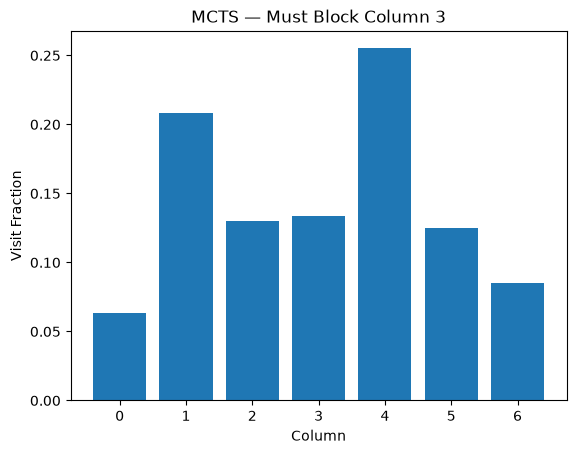

Board:
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
Required blocking move: column 3

Raw neural network:
Value: 0.030475309118628502
Policy: [0.06592405 0.19247517 0.15942954 0.11446044 0.2561941  0.1151934
 0.09632333]
NN preferred move: 4

MCTS:
Policy: [0.03833333 0.24833333 0.07166667 0.08166667 0.145      0.35333333
 0.06166667]
MCTS preferred move: 5


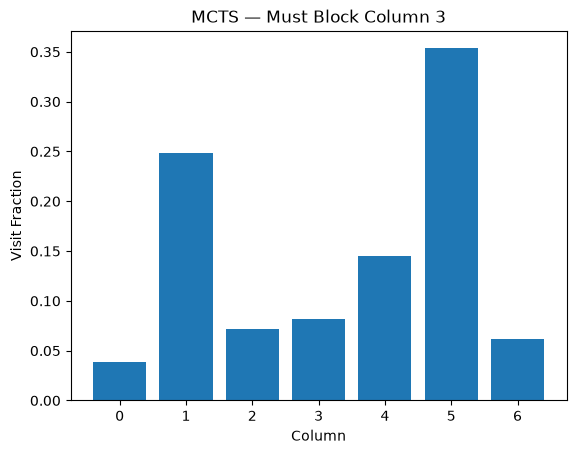

Board:
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
Required blocking move: column 3

Raw neural network:
Value: 0.03845810517668724
Policy: [0.05008488 0.24327345 0.08827026 0.09897707 0.1235703  0.2987073
 0.09711671]
NN preferred move: 5

MCTS:
Policy: [0.05166667 0.22833333 0.11166667 0.03333333 0.045      0.325
 0.205     ]
MCTS preferred move: 5


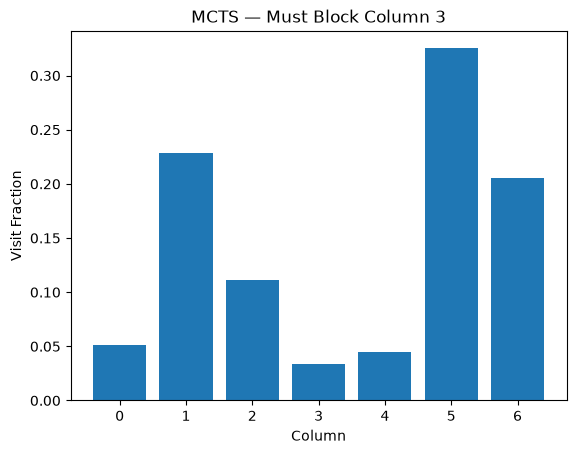

Board:
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
Required blocking move: column 3

Raw neural network:
Value: 0.07553587108850479
Policy: [0.05296811 0.17701763 0.13833256 0.05037386 0.05107491 0.28553343
 0.24469948]
NN preferred move: 5

MCTS:
Policy: [0.08       0.23333333 0.09       0.06833333 0.01166667 0.24666667
 0.27      ]
MCTS preferred move: 6


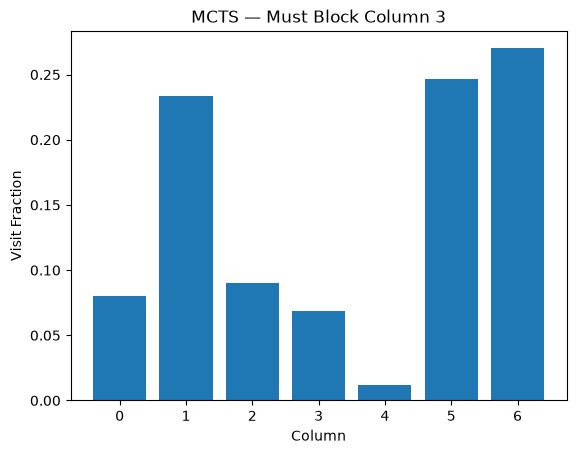

Board:
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
Required blocking move: column 3

Raw neural network:
Value: 0.06427816301584244
Policy: [0.12957832 0.24336758 0.1063113  0.07165939 0.01880151 0.20037116
 0.22991067]
NN preferred move: 1

MCTS:
Policy: [0.045      0.10666667 0.09333333 0.01666667 0.52333333 0.13666667
 0.07833333]
MCTS preferred move: 4


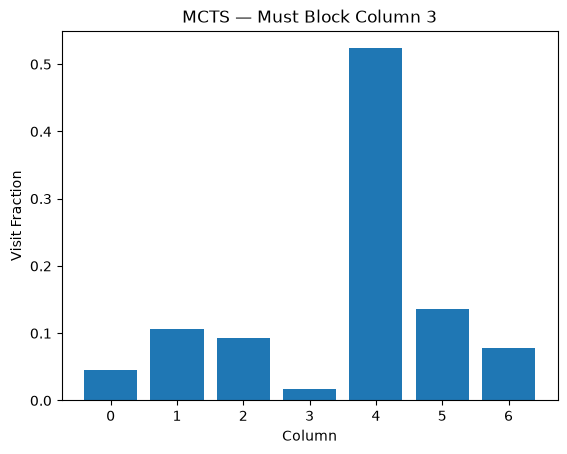

Board:
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
Required blocking move: column 3

Raw neural network:
Value: 0.03799109905958176
Policy: [0.04796572 0.09850623 0.09712908 0.03560863 0.5103467  0.14054683
 0.06989679]
NN preferred move: 4

MCTS:
Policy: [0.01666667 0.045      0.02833333 0.015      0.72       0.145
 0.03      ]
MCTS preferred move: 4


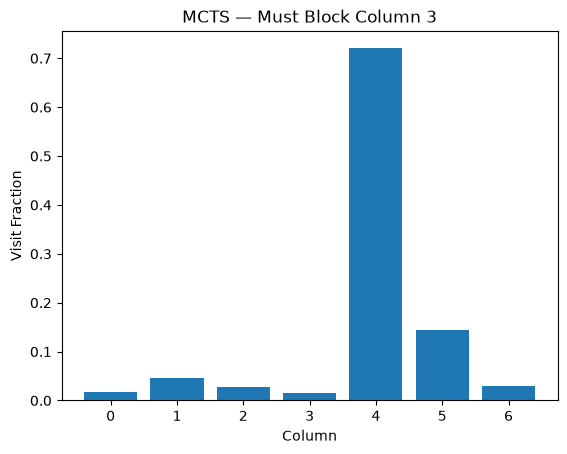

Board:
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
Required blocking move: column 3

Raw neural network:
Value: 0.032352302223443985
Policy: [0.02742974 0.0541118  0.03389011 0.02438522 0.6580061  0.15869406
 0.04348298]
NN preferred move: 4

MCTS:
Policy: [0.005      0.01833333 0.02666667 0.16166667 0.43       0.34333333
 0.015     ]
MCTS preferred move: 4


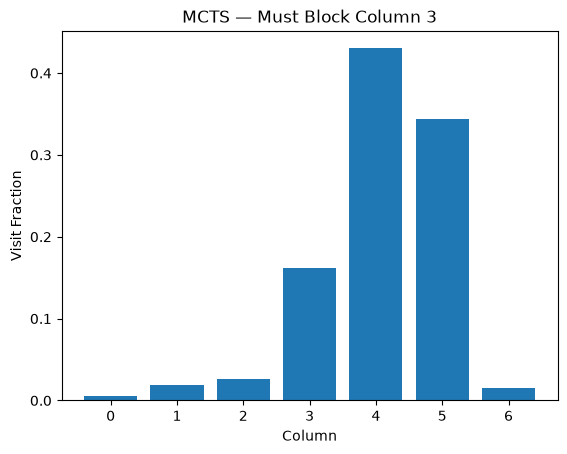

Board:
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
Required blocking move: column 3

Raw neural network:
Value: 0.10877902805805206
Policy: [0.01074983 0.0280644  0.04107948 0.16536033 0.32649323 0.3987388
 0.02951382]
NN preferred move: 5

MCTS:
Policy: [0.         0.00833333 0.32333333 0.09666667 0.36833333 0.17
 0.03333333]
MCTS preferred move: 4


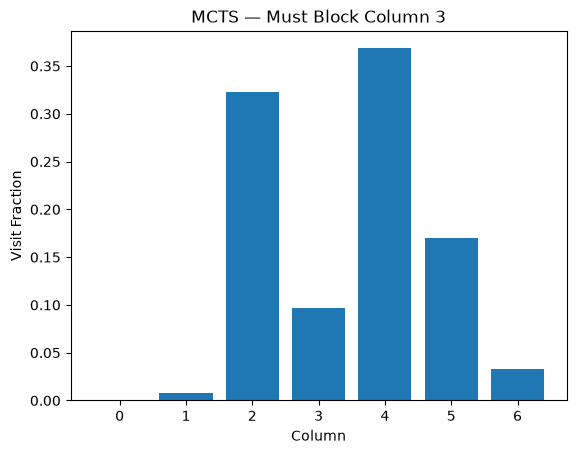

In [26]:
for i in range(8):
    model.load_state_dict(
        torch.load(
            f"model_{i}_ConnectFour.pt",
            map_location=device
        )
    )
    model.eval()

    # evaluate empty board policy here
    state = game.get_initial_state()
    
    
    # It is +1's turn.
    #
    # Bottom row:
    #
    # O O O . X X .
    # 0 1 2 3 4 5 6
    #
    # We MUST play column 3.
    # Otherwise -1 wins immediately next turn.
    
    player = 1
    neutral_state = game.change_perspective(state, player)
    
    print("Board:")
    print(state)
    print("Required blocking move: column 3")
    
    # ---------- Raw neural network ----------
    
    encoded_state = game.get_encoded_state(neutral_state)
    
    tensor_state = torch.tensor(
        encoded_state,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)
    
    with torch.no_grad():
        policy_logits, value = model(tensor_state)
    
    nn_policy = torch.softmax(
        policy_logits,
        dim=1
    ).squeeze(0).cpu().numpy()
    
    print("\nRaw neural network:")
    print("Value:", value.item())
    print("Policy:", nn_policy)
    print("NN preferred move:", np.argmax(nn_policy))
    
    
    # ---------- MCTS ----------
    
    mcts = AlphaMCTS(game, args, model)
    
    mcts_policy = mcts.search(neutral_state)
    
    print("\nMCTS:")
    print("Policy:", mcts_policy)
    print("MCTS preferred move:", np.argmax(mcts_policy))
    
    
    plt.bar(range(game.action_size), mcts_policy)
    plt.xlabel("Column")
    plt.ylabel("Visit Fraction")
    plt.title("MCTS — Must Block Column 3")
    plt.show()

In [30]:
import kaggle_environments
print(kaggle_environments.__version__)

class KaggleAgent:
    def __init__(self, model, game, args):
        self.model = model
        self.game = game
        self.args = args
        if self.args['search']:
            self.mcts = AlphaMCTS(self.game, self.args, self.model)
    def run(self, obs, conf):
        player = obs['mark'] if obs['mark'] == 1 else -1
        state = np.array(obs['board']).reshape(self.game.row_count, self.game.column_count)
        state[state==2] = -1


        #these two if statements are changed to add in neutral state
        if self.args['search']:
            neutral_state = self.game.change_perspective(state, player)
            policy = self.mcts.search(neutral_state)
    
        else:
            neutral_state = self.game.change_perspective(state, player)
            policy, _ = self.model.predict(
                neutral_state,
                argument=self.args['argument']
            )


        valid_moves = self.game.get_valid_moves(state)
        policy *= valid_moves
        policy /= np.sum(policy)

        if self.args['temperature'] == 0:
            action = int(np.argmax(policy))
        elif self.args['temperature'] == float('inf'):
            action = np.random.choice([r for r in range(self.game.action_size) if policy[r] > 0])
        else:
            policy = policy ** (1/self.args['temperature'])
            policy /= np.sum(policy)
            action = np.random.choice(self.game.action_size, p = policy)
        return action

#test for connect four games
game = ConnectFour()

args = {
    'C': 2,
    'num_searches': 600,
    'dirichlet_epsilon':0.0, #randomness
    'dirichlet_alpha':0.3, 
    'search': True,
    'temperature': 0,
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNet(game, 9, 128, device)
model.load_state_dict(torch.load("model_7_ConnectFour.pt", map_location = device))
model.eval()

env = kaggle_environments.make("connectx")

player1 = KaggleAgent(model, game, args)
player2 = KaggleAgent(model, game, args)

players = [player1.run, player2.run]

player = []
env.run(players)
env.render(mode = "ipython")



1.32.7


In [16]:
#test for tictactoe games
game = TicTacToe()

args = {
    'C': 2,
    'num_searches': 100,
    'dirichlet_epsilon':0.1, #randomness
    'dirichlet_alpha':0.3, 
    'search': True,
    'temperature': 0,
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNet(game, 4, 64, device)
model.load_state_dict(torch.load("model_2.pt", map_location = device))
model.eval()

#issue, will fix later
env = kaggle_environments.make("tictactoe")

player1 = KaggleAgent(model, game, args)
player2 = KaggleAgent(model, game, args)

players = [player1.run, player2.run]

player = []
env.run(players)
env.render(mode = "ipython")


InvalidArgument: Unknown Environment Specification